# PCHN63112 Workshop: Three-level Clustered Data Example
In this example,we will examine building a mixed-effects model for clustered data that contains three levels of variation. This will demonstrate how the multilevel framework extends beyond two levels, as well as how this can be integrated into a mixed-effects model. This is also a much larger example, with many variables available. This will lead to a more complex expression for the model, but one which is a simple generalisation of other examples we have seen.

## Loading Packages
We will start by loading all the packages that we need at the beginning. This will tidy-up the output, allow any messages or warnings to not clutter up the rest of the output and not bury any packages within the main body of the analysis. We also use `source()` on the file `plot-lme.R`. This needs to be in the current working directory and will bring the custom function `plot.lme()` into scope.

In [1]:
library('lattice')   # plotting functions
library('nlme')      # mixed-effects modelling
library('car')       # Asymptotic ANOVA tests and VIF
library('effects')   # Effects plots from the model
source('plot-lme.R') # custom plot.lme() function for making assumptions plots

Loading required package: carData
Use the command
    lattice::trellis.par.set(effectsTheme())
  to customize lattice options for effects plots.
See ?effectsTheme for details.


## The Classroom Data
The data we will use concern measurements of improvement in maths ability in a selection of students from different classrooms across different schools. In total, these data contains measurements from 1,190 students from 312 classrooms from 107 schools. Importantly, these data were measured from first-graders in the USA (ages 6-7). As such, all students stay within the *same* classroom with the *same* teacher for the whole year. A wide variety of additional variables were captured describing the local area of the school, the teacher's experience and maths knowledge, and the student's demographic details. 

The data can be downloaded from [here](https://websites.umich.edu/~bwest/chapter4.html). Once downloaded to the current working directory, the code below will read the data into `R` and then print values for the first two classrooms from the first school

In [2]:
classroom <- read.csv('classroom.csv')
print(classroom[1:11,])

   sex minority mathkind mathgain   ses yearstea mathknow housepov mathprep
1    1        1      448       32  0.46        1       NA    0.082     2.00
2    0        1      460      109 -0.27        1       NA    0.082     2.00
3    1        1      511       56 -0.03        1       NA    0.082     2.00
4    0        1      449       83 -0.38        2    -0.11    0.082     3.25
5    0        1      425       53 -0.03        2    -0.11    0.082     3.25
6    1        1      450       65  0.76        2    -0.11    0.082     3.25
7    0        1      452       51 -0.03        2    -0.11    0.082     3.25
8    0        1      443       66  0.20        2    -0.11    0.082     3.25
9    1        1      422       88  0.64        2    -0.11    0.082     3.25
10   0        1      480       -7  0.13        2    -0.11    0.082     3.25
11   0        1      502       60  0.83        2    -0.11    0.082     3.25
   classid schoolid childid
1      160        1       1
2      160        1       2
3   

There are quite a few variables here, so we split them into those that relate to each *school* as a whole, each *classroom* as a whole and each *pupil* as a whole.

- School
    - `schoolid`: the unique index of each *school*
    - `housepov`: proportion of households in the local area below the poverty line
- Classroom
    - `classid`: the unique index of each *classroom*
    - `yearstea`: the teacher's years of experience
    - `mathprep`: the amount of training in mathematics education the teacher has undertaken
    - `mathknow`: the amount of mathematics knowledge the teacher has
- Student
    - `childid`: the unique index of each *student*
    - `mathgain`: **the student's gain in maths achievement over the year**
    - `sex`: the student's sex
    - `mathkind`: the student's maths score in the previous (kindergarten) year
    - `minority`: whether the student is from an ethnic minority background
    - `ses`: the student's socioeconomic status

Some of these variables are indices to keep things organised and to allow us to define different levels of the data: `schoolid`, `classid`, `childid`. The outcome variable is `mathgain`, highlighted in **bold**, indicative of how much the student has improved over the year spent in one particular classroom. This leaves *eight* potential predictor variables that could explain why some students improve more than others.

As these data are already long-formatted, we just need to convert the relevant variables to factors. We also choose to relabel both `sex` and `minority` to make their meaning clearer

In [3]:
classroom$classid  <- as.factor(classroom$classid)
classroom$schoolid <- as.factor(classroom$schoolid)
classroom$sex      <- as.factor(classroom$sex)
classroom$minority <- as.factor(classroom$minority)

levels(classroom$sex)      <- c('boy','girl')
levels(classroom$minority) <- c('nonminority', 'minority')

We can now briefly summarise all the variables. At this stage, we would usually produce some plots and do further data checking and wrangling, but we will leave this step to one side to keep the example shorter.

In [4]:
summary(classroom)

   sex             minority      mathkind        mathgain      
 boy :588   nonminority:384   Min.   :290.0   Min.   :-110.00  
 girl:602   minority   :806   1st Qu.:439.2   1st Qu.:  35.00  
                              Median :466.0   Median :  56.00  
                              Mean   :466.7   Mean   :  57.57  
                              3rd Qu.:495.0   3rd Qu.:  77.00  
                              Max.   :629.0   Max.   : 253.00  
                                                               
      ses              yearstea        mathknow          housepov     
 Min.   :-1.61000   Min.   : 0.00   Min.   :-2.5000   Min.   :0.0120  
 1st Qu.:-0.49000   1st Qu.: 4.00   1st Qu.:-0.7200   1st Qu.:0.0850  
 Median :-0.03000   Median :10.00   Median :-0.1300   Median :0.1270  
 Mean   :-0.01298   Mean   :12.21   Mean   : 0.0312   Mean   :0.1782  
 3rd Qu.: 0.39750   3rd Qu.:20.00   3rd Qu.: 0.8500   3rd Qu.:0.2550  
 Max.   : 3.21000   Max.   :40.00   Max.   : 2.6100   Max.   :

Some elements of note from these summaries:
- `sex` is balanced, so there is unlikely to be a bias here in terms of sex-related differences in attainment.
- `minority` indicates that the majority of the sample are from ethnic minority backgrounds ($806/(806+384) \times 100 = 67.73\%$).
- Some children have *negative* `mathgain` scores, indicating that they got *worse* over the year.
- There is a wide variation in `yearstea`, with some teachers having 40 years of experience and others having 0 years of teaching.
- There is also wide variation in `housepov`, with some school in area with very little poverty (1% of local houses) and some schools in areas with high poverty (56% of local houses).
- There are missing values in `mathknow`, as some teachers were not measured. 

### Model Notation
As these data are a mixture of *categorical* and *continuous* variables, a more general regression framework will be needed when writing this model. In what follows, we will use *descriptive labels* rather than greek letter for categorical variables (e.g. $\text{sex}_{j}$ rather than $\alpha_{j}$) and will introduce $\beta$-coefficients for continuous variables (e.g. $\beta_{1} \times \text{mathknow}_{i}$ rather than $\beta_{1}x_{i1}$). This should hopefully make it clearer which terms are categorical and which are continuous. In reality, the whole model is fit as a regression with dummy variables in place of the categorical predictors. However, it can be less clear to write the model this way, even if this is the reality of how it is fit.

## Data Structure
Although we already know what structure these data have, we will run through the logic for completeness.

Firstly, we need to determine our *unit of analysis*. In this example, our model is trying to explain improvements in maths scores in *students*. The entities that our model is describing are the *students* themselves, so these are our units of analysis.

Secondly, we determine what each *row* of the long-formatted data represents in relation to the units of analysis. Examining the first few rows

In [5]:
head(classroom)

   sex minority mathkind mathgain   ses yearstea mathknow housepov mathprep
1 girl minority      448       32  0.46        1       NA    0.082     2.00
2  boy minority      460      109 -0.27        1       NA    0.082     2.00
3 girl minority      511       56 -0.03        1       NA    0.082     2.00
4  boy minority      449       83 -0.38        2    -0.11    0.082     3.25
5  boy minority      425       53 -0.03        2    -0.11    0.082     3.25
6 girl minority      450       65  0.76        2    -0.11    0.082     3.25
  classid schoolid childid
1     160        1       1
2     160        1       2
3     160        1       3
4     217        1       4
5     217        1       5
6     217        1       6

we can see that each row corresponds to a single unit (*student*) measured *once*. So these are neither repeated measurements or longitudinal data. 

Finally, we need to determine whether there are any *clustering* variables that represent a higher-order dependency structure in these data. From what we can see above, there are several variables that are *constant* across multiple students: `yearstea`, `mathknow`, `housepov`, `mathprep`, `classid` and `schoolid`. Of those, only `classid` and `schoolid` are categorical and so are the only candidates for either *grouping variables* or *clustering variables*. 

In terms of thinking about clustering variables as representative of a *shared environment*, both `classid` and `schoolid` fit the description. These are both elements that each student is *IN* rather than something each student *HAS*. Students within a classroom may be correlated by virtue of sharing a teacher, sharing the same corpus of classmates and sharing the same teaching environment. Similarly, classrooms within a school may be correlated by virtue of sharing the same physical location, the same school budget and the same senior members of staff. The different schools represent the top boundary of dependence, because different schools will be independent of each other. Within a school, each classroom will have a degree of independence, as these are separate entities. However, they will also share a degree of dependence due to being within the same school. So this is a separate boundary of dependence. We imagine these as smaller covariance blocks within a larger covariance block.

Based on this, we can construct the following table of the *levels* of these data, using the guidance in the lesson

| **Data Type**    | **Clustered** | 
|------------------|---------------|
| **Dataset**      | `classroom`   |
| **Level 1**      | *Student*     |
| **Level 2**      | Classroom     |
| **Level 3**      | School        |

We could also imagine a more complex version of these data, where each student was measured at multiple points within a year. This would then be *longitudinal* clustered data with *four* levels. We would have the longitudinal measurements at Level 1, student at Level 2, classroom at Level 3 and school at Level 4. This would lead to quite a complex dependency structure that would be very difficult to reason about and build using a method like GLS. However, the mixed-effects framework allows us to build this carefully in layers, without every having to touch the covariance structure.

## Model Building
To build a model of this dataset, we use the 3-step procedure outlined in the lesson. We assume at this point that the data has been investigated, wrangled, cleaned and ready for modelling.

### Step I: A Single Dependency Structure
We start by isolating a single dependency structure. This needs to be at the *lowest* level, with no further dependency structures within. In this example, this is a single *classroom*. We choose `classid == '174'` for this purpose, after examining several candidates. This was chosen because it contains a reasonable number of measurements (7 students), has no missing data and has representation of *both* levels of `minority`. During this exploration, it was notable that many classrooms are *constant* in terms of `minority`, which will be important to bear in mind when fitting the model. 

In [6]:
classroom.1 <- subset(classroom, classid=='174')
print(classroom.1)

     sex    minority mathkind mathgain   ses yearstea mathknow housepov
912 girl    minority      474       90  0.04       11     1.75     0.21
913  boy nonminority      430       74 -0.03       11     1.75     0.21
914 girl nonminority      452       44 -0.67       11     1.75     0.21
915 girl nonminority      428       53 -0.42       11     1.75     0.21
916  boy    minority      452       66 -0.73       11     1.75     0.21
917 girl nonminority      485       40 -0.78       11     1.75     0.21
918 girl    minority      458       48 -0.44       11     1.75     0.21
    mathprep classid schoolid childid
912        2     174       81     912
913        2     174       81     913
914        2     174       81     914
915        2     174       81     915
916        2     174       81     916
917        2     174       81     917
918        2     174       81     918


In terms of the variables suitable for an individual model of a single classroom, we note that many of the variables above are *constant* because they are defined either at the level of a *classroom* as a whole, or a *school* as a whole. As such, they are not suitable for modelling the individual students. We remove these below 

In [7]:
classroom.1 <- subset(classroom, classid=='174', select=c(-yearstea,-mathknow,-housepov,-mathprep,-classid,-schoolid))
print(classroom.1)

     sex    minority mathkind mathgain   ses childid
912 girl    minority      474       90  0.04     912
913  boy nonminority      430       74 -0.03     913
914 girl nonminority      452       44 -0.67     914
915 girl nonminority      428       53 -0.42     915
916  boy    minority      452       66 -0.73     916
917 girl nonminority      485       40 -0.78     917
918 girl    minority      458       48 -0.44     918


Based on this, our basic model for a single classroom is

$$
\text{mathgain}_{ijk} = \text{mean} + \text{sex}_{j} + \text{minority}_{k} + (\beta_{1} \times \text{mathkind}_{i}) + (\beta_{2} \times \text{ses}_{i}) + \eta_{ijk}
$$

where $i$ indexes the student, $j$ indexes `sex` and $k$ indexes `minority`. Both $\text{sex}_{j}$ and $\text{minority}_{k}$ are indicative of categorical effects, whereas $\text{mathkind}_{i}$ and $\text{ses}_{i}$ are indicative of continuous predictors with associated regression slopes $\beta_{1}$ and $\beta_{2}$.

We can fit this model in `R` as shown below

In [8]:
class.1.lm <- lm(mathgain ~ 1 + sex + minority + mathkind + ses, data=classroom.1)
summary(class.1.lm)


Call:
lm(formula = mathgain ~ 1 + sex + minority + mathkind + ses, 
    data = classroom.1)

Residuals:
    912     913     914     915     916     917     918 
  6.898  -5.146   2.530   4.895   5.146  -2.279 -12.043 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)
(Intercept)        8.9519   125.7963   0.071    0.950
sexgirl          -14.1331    11.4198  -1.238    0.341
minorityminority   7.8017    10.3018   0.757    0.528
mathkind           0.1662     0.2936   0.566    0.628
ses               42.4991    15.7473   2.699    0.114

Residual standard error: 11.86 on 2 degrees of freedom
Multiple R-squared:  0.8578,	Adjusted R-squared:  0.5735 
F-statistic: 3.017 on 4 and 2 DF,  p-value: 0.2641


However, notice that there are only 2 residual degrees of freedom left, because we have fit 5 parameters to 7 datapoints. If we had fewer students in this class, the model would fail to fit. Unfortunately, the data are quite limited for most of the classrooms in this dataset. To see this, we use the code below to select 20 random classrooms and then plot them as panels with `sex` on the $x$-axis and different symbols used to indicate the levels of `minority`.

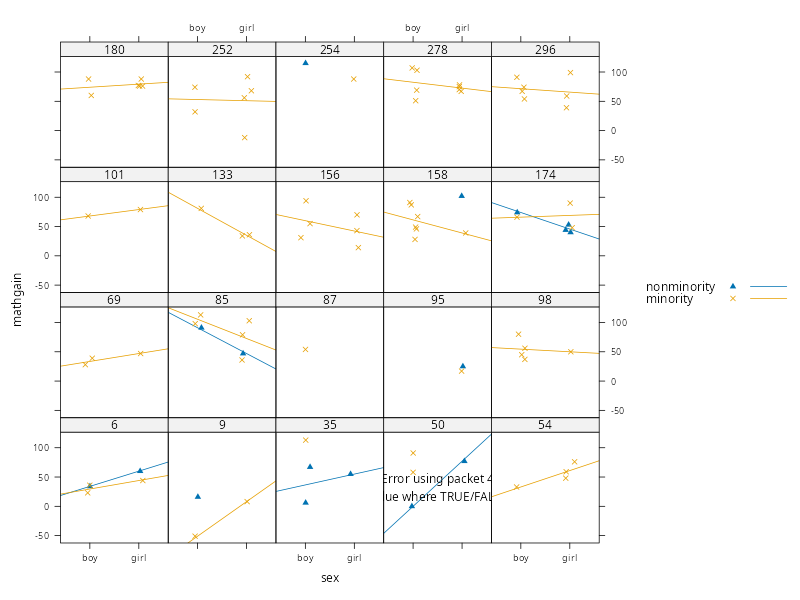

In [9]:
set.seed(666)
keep.IDs <- sample(unique(classroom$classid), 20)      # select 20 random class IDs

xyplot(mathgain ~ sex | classid,                       # x-axis=sex, panels=classroom
  groups   = minority,                                 # minority different symbols
  data     = subset(classroom, classid %in% keep.IDs), # only random class IDs
  type     = c('p','r'),                               # points and regression lines
  auto.key = TRUE,                                     # add key
  jitter.x = TRUE,                                     # jitter points for visibility
  par.settings = list(
    superpose.symbol = list(
      pch = c(17,4)                                    # symbols to triangle and cross
    )
  )
)

As we can see, some classrooms have much less data than others. In many cases, there is only a single level of `minority` represented. Some classrooms only have a single student who was measured, whereas in others multiple students were measured but only of one `sex`. This suggests already that data will need be to pooled across classrooms in order to estimate the effects of `sex` and `minority`, potentially precluding the idea of allowing `sex` and `minority` to vary per-classroom.

### Step II: Expand to Multiple Structures
In our second step, we expand the model above to *multiple* classrooms. We index these using the notation of $(c)$, to indicate which terms *belong* to a particular *classroom*. We start with the most general case of allowing every term to vary by-classroom, giving us

$$
\text{mathgain}^{(c)}_{ijk} = \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta_{1}^{(c)} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk}
$$

We can now reason more carefully about each of these.

In terms of $\text{mean}^{(c)}$, if we want to use a mixed-effects models then the bear minimum is a *random intercept* term. Allowing $\text{mean}^{(c)}$ to differ per-classroom implies that each classroom is a random sample from a distribution of classrooms. The degree of $\text{mathgain}$ depends upon the specific classroom environment and the specific teacher, rather than being the same across all classrooms. If it were the same, this would imply that any differences across students are down to the student's own characteristics and it would not matter if the student was in a different classroom or in a different school. In this scenario, the classroom has no bearing on the outcome. Instead, we can choose treat each classroom as a distribution of $\text{mathgain}$ scores with its own specific average value of $\text{mathgain}$ that will differ from other classrooms. In this scenario, the classroom *does* have an effect on the outcome, implying that an individual student may perform differently in a different classroom. In addition, given that `classroom` is our clustering variable, it is usually sensible to treat this as *random* rather than *fixed*.

The remaining terms in this individual-classroom model present something of a challenge. For each of these, consider the implication of treating them as *random* rather than *fixed*

- $\text{sex}^{(c)}_{j}$ &mdash; Any differences in $\text{mathgain}$ between boys and girls depends upon the classroom environment, with some teachers able to close gaps and some potentially widening gaps.
- $\text{minority}^{(c)}_{k}$ &mdash; Any differences in $\text{mathgain}$ between minority and non-minority children depends upon the classroom environment, with some teachers able to close gaps and some potentially widening gaps.
- $\beta_{1}^{(c)}$ &mdash; The relationship between a student's kindergarten score and their eventual value of $\text{mathgain}$ depends upon the classroom environment, with some teachers associated with a much stronger relationship than others.
- $\beta_{2}^{(c)}$ &mdash; The relationship between a student's socioeconomic status their eventual value of $\text{mathgain}$ depends upon the classroom environment, with some teachers associated with a much stronger relationship than others.

In all cases, simply reasoning about these terms will depend upon how much we believe teachers are able to influence individual students, despite their characteristics. This can get a bit philosophical, depending upon whether we believe students are handed to teachers as a *tabula rasa*, available for molding in whatever shape the teacher desires, or whether there are pre-existing characteristics of each student that will dictate performance, despite the efforts of individual teachers. Certainly, we could imagine individual teachers who are able to create an environment where students can excel irrespective of these factors, but do we believe this is something that varies enough across different classrooms and schools to offset any strong global pattern, or would this just effectively be sampling noise?

We could also take a more data-driven approach to this decision. For instance, we could plot the data for `mathkind` within those classrooms randomly sampled earlier

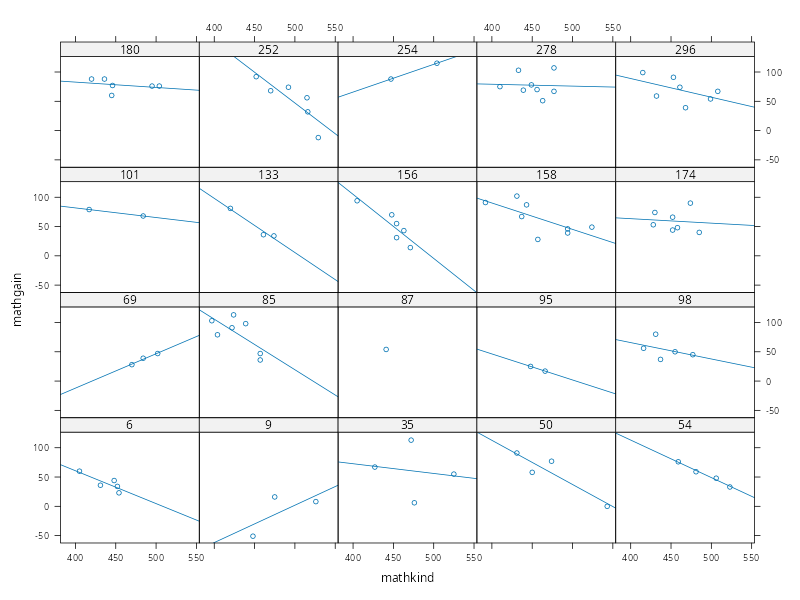

In [10]:
xyplot(mathgain ~ mathkind | classid,              # x-axis=mathkind, panels=classroom
  data = subset(classroom, classid %in% keep.IDs), # only random class IDs
  type = c('p','r'),                               # points and regression lines
)

Although the slopes are a bit all over the place, we need to consider the amount of data within each classroom. Notice that the vast majority of slopes are *negative*, which suggests a global pattern where the greater the student's earlier performance, the less improvement they will make. In addition, many classrooms do have a similar magnitude of slope. Those with something much more extreme are often those with a much narrower range of `mathkind` scores. So, unfortunately, it is very hard to tell whether these slopes represent fundamental differences between the classrooms, or are simply a result of sampling noise. At this stage, this does not help with the question of *random* or *fixed* meaning that the data-driven approach is less useful here. We need to therefore use reason, practical limitations and model comparisons to make a decision.



It was recommended in the accompanying lesson that in cases of uncertainty we simply treat everything as random and then use model comparisons. However, there is a catch with this approach. If we do this here, then we have 5 random effects, which will mean 5 error terms and 5 variances, as well as correlations between all of them. This tends to be too much for most random effects algorithms. So even if we desire this *theoretically*, in terms of *practicality* we will be forced to simplify. Nervousness about fitting this model is also justified when we consider that the amount of data per-classroom is very limited, with only a small number that would be able to fit the full model we want. This means that a lot of pooling and shrinkage will be going on, with many of the effects based on *no data* for that particular classroom. Indeed, the average number of students per-classroom is

In [11]:
mean(table(classroom$classid))

[1] 3.814103

which is *very small*. Realistically, if we want the full random-effects specification we need *much larger* samples within each classroom. Of course, we could power through and see whether a model with all these random terms can be fit, but we will save you the trouble and tell you that it *cannot*. This is more of a *brute force* approach, which we do not recommend, but ultimately there is no harm in trying. So, we do need to simplify at this point. 

On the basis that it quite a strong assumption to think that individual teachers are able to undo any fundamental effects of sex, minority status, existing maths achievement and socioeconomic status, we choose to treat all these terms as *fixed*, leaving only the intercept as *random*. This implies that individual teachers and classroom environments are able to raise or lower all values of $\text{mathgain}$ by some amount. So, under some teachers all students do better or worse, like a rising tide lifting all boats. However, *within* those students, there are global effects of sex, minority status, prior achievement and socioeconomic status that are in play that do not depend upon an individual teacher or classroom environment. Although this does create something of a *fatalistic* perspective on student performance, it does have the benefit of greatly simplifying the random-effects structure. 

### Step III: Write the Higher-level Models
Now that we have made a decision about all the Level 1 terms, we can write the Level 2 models for each term. As $\text{mean}^{(c)}$ is the only *random* term, it is the only Level 2 model with an error term. This gives

$$
\begin{alignat*}{1}
\text{Level 1 (Student)} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta^{(c)}_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2 (Classroom)} \\
    \text{mean}^{(c)}         &= \text{mean} + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1} \\
    \beta^{(c)}_{2}           &= \beta_{2}.
\end{alignat*}
$$

At this point, we can decide whether there are any classroom-level variables we also want to include in these models. Looking back to our data description from earlier, the additional variables we have available are `yearstea`, `mathprep` and `mathknow`. These apply to individual teachers *as a whole* and thus could be used to explain average `mathgain` for a whole class. As such, our first option is to add these variables as predictors of $\text{mean}^{(c)}$, giving

$$
\begin{alignat*}{1}
\text{Level 1 (Student)} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta^{(c)}_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2 (Classroom)} \\
    \text{mean}^{(c)}         &= \text{mean} + \left(\beta_{3} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1} \\
    \beta^{(c)}_{2}           &= \beta_{2}.
\end{alignat*}
$$

Our next option is whether to include these predictor within the models for the remaining effects of `sex`, `minority`, `mathkind` and `ses`. Because these are models of individual effects, any additional predictors will enter as *interactions* with that effect. In order to keep things simple, we will not entertain the possibility of interactions here. In general, we would need strong reasons for including them, given that additional complexity they add. For instance, if we had strong reason to think that `yearstea` influences the difference in attainment between boys and girls, we could add $\beta_{6} \times \text{sex}_{j} \times \text{yearstea}^{(c)}$ to the model of $\text{sex}^{(c)}_{j}$. This would imply that the regression slope between years of teaching experience and maths attainment differs between boys and girls. Perhaps more experienced teachers are able to close the gap more than less experienced teachers? Although plausible, this is an additional level of complexity that may not be warranted without good evidence to suggest that this is the case. To keep things simple, we will not include this. 

#### Expand to Multiple Schools
At this point, we have a perfectly useable two-level model that would be suitable for *one school*. However, we know that we have an additional level of clustering in the form of *different schools*. This means we need to repeat some of our process from above, but for Level 2 instead. So, let us take the Level 2 specification and expand it to *multiple schools*. We will use a similar notation to earlier, where terms that can differ by school are indicated by superscript $(s)$. If we start by allowing every term to vary by-school, we get

$$
\begin{alignat*}{1}
\text{Level 2} \\
    \text{mean}^{(c)}         &= \text{mean}^{(s)} + \left(\beta_{3}^{(s)} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4}^{(s)} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5}^{(s)} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}^{(s)}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}^{(s)}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1}^{(s)} \\
    \beta^{(c)}_{2}           &= \beta_{2}^{(s)} \\ \quad \\
\end{alignat*}
$$

So, we now have to work through each of the new school-specific terms and decide whether to treat them as *fixed* or *random*. In other words, is each term allowed to differ *across schools* or not. 

This is a similar process to reasoning about individual classrooms. The minimum we need to accommodate the influence of different schools is to allow the *mean* to differ across schools. So, we opt to treat $\text{mean}^{(s)}$ as *random*. This captures the idea that each school is a random sample from a population of schools and that our inference is not restricted to only those schools in our sample. 

The remaining terms represent a similar complexity to earlier. Although we *could* keep each one as random, it is very unlikely that the data would support this. Again, you could *try* but it is likely that this will fail. So, we already desire some degree of *simplification*. If we take $\beta_{3}$ as an example, this is the regression slope associated with the experience of each teacher. If we leave this as *fixed* we are suggesting that the relationship between years of experience and maths improvement is a global effect across all schools. There is no influence of different schools here, there is just a general pattern that (for instance) more experienced teachers are able to engineer the biggest improvements. If we make this *random*, we are suggesting that the effect of teacher experience differs on a per-school basis. This seems less likely, but we could imagine a scenario where some schools give teachers more freedom to adapt their teaching style and make use of their experience, whereas others may be more rigid in their requirements. In reality, most schools probably would not be able to completely neuter a teacher's years of experience from influencing student grades. In fact, this would never really be desirable. So, in this case, given our additional desire for simplicity, we choose to treat $\beta_{3}$ as *fixed*. In other words, the effect of teacher experience on improvements in maths grades does not depend upon the school they happen to work in.

We can reason about the terms such as $\beta_{4}$ (the relationship between maths scores and teacher preparation) and $\beta_{5}$ (the relationship between maths scores and teacher knowledge) in a similar way and reach a similar conclusion that these terms can be *fixed*. Terms such as $\beta_{1}$ (the relationship between maths scores and earlier attainment), $\beta_{2}$ (the relationship between maths scores and socioeconomic status), $\text{sex}_{j}$ and $\text{minority}_{k}$ are a little trickier. However, in these cases it seems unlikely that there would be vast school-specific differences here. It could be that some schools have campaigns designed to reduce performance gaps between sexes, or have specific measures in place to target students will low earlier attainment. However, we need this to be a enough of a consistent difference across schools to create vastly different relationships that depend upon each school individually. Given that we have no knowledge of this, it becomes somewhat fanciful and so, with no other information to hand about these school differences, we choose to fix these terms as well. So, our level 3 model is now

$$
\begin{alignat*}{1}
\text{Level 3 (School)} \\
    \text{mean}^{(s)} &= \text{mean} + \phi^{(s)} \\
    \text{sex}^{(s)}_{j} &= \text{sex}_{j} \\
    \text{minority}^{(s)}_{k} &= \text{minority}_{k} \\
    \beta_{1}^{(s)} &= \beta_{1} \\
    \beta_{2}^{(s)} &= \beta_{2}\\
    \beta_{3}^{(s)} &= \beta_{3} \\
    \beta_{4}^{(s)} &= \beta_{4} \\
    \beta_{5}^{(s)} &= \beta_{5} \\
\end{alignat*}
$$

Because $\text{mean}^{(s)}$ is the only *random* term, this is the only model with an error-term. This means we will be able to simplify this specification down dramatically, but we keep it in its full form for the moment.

Our final step is deciding whether there are any *school-level* variables that we wish to include in the Level 3 models. Looking back at the data description from earlier, we can see that the only school-level variable is `housepov`, representing the proportion of local houses around the school that are below the poverty line. As we saw at Level 2, this will enter first as an additional predictor for the mean, suggesting that average maths attainment within a specific school is influenced by the amount of local poverty. For the remaining models, this would enter as an interaction with the term being modelled. For instance, we could explain the effect of `sex` across schools in terms of a global effect of `sex` plus the interaction between `sex` and `housepov`. This would imply that the degree of local poverty impacts boys and girls differently, in terms of their maths attainment. This does not seem a wholly obvious thing to include in the model without having more information to suggest otherwise. So, much like the Level 2 model, we maintain simplicity by not entertaining any additional interactions.Based on all this, the final Level 3 specification is

$$
\begin{alignat*}{1}
\text{Level 3 (School)} \\
    \text{mean}^{(s)} &= \text{mean} + \left(\beta_{6} \times \text{housepov}^{(s)}\right) + \phi^{(s)} \\
    \text{sex}^{(s)}_{j} &= \text{sex}_{j} \\
    \text{minority}^{(s)}_{k} &= \text{minority}_{k} \\
    \beta_{1}^{(s)} &= \beta_{1} \\
    \beta_{2}^{(s)} &= \beta_{2}\\
    \beta_{3}^{(s)} &= \beta_{3} \\
    \beta_{4}^{(s)} &= \beta_{4} \\
    \beta_{5}^{(s)} &= \beta_{5} \\
\end{alignat*}
$$

#### The Final Model (Full and Simplified)
The full model is now (*deep breath*)

$$
\begin{alignat*}{1}
\text{Level 1 (Student)} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta^{(c)}_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2 (Classroom)} \\
    \text{mean}^{(c)}         &= \text{mean}^{(s)} + \left(\beta_{3}^{(s)} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4}^{(s)} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5}^{(s)} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}^{(s)}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}^{(s)}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1}^{(s)} \\
    \beta^{(c)}_{2}           &= \beta_{2}^{(s)} \\ \quad \\
\text{Level 3 (School)} \\
    \text{mean}^{(s)} &= \text{mean} + \left(\beta_{6} \times \text{housepov}^{(s)}\right) + \phi^{(s)} \\
    \text{sex}^{(s)}_{j} &= \text{sex}_{j} \\
    \text{minority}^{(s)}_{k} &= \text{minority}_{k} \\
    \beta_{1}^{(s)} &= \beta_{1} \\
    \beta_{2}^{(s)} &= \beta_{2}\\
    \beta_{3}^{(s)} &= \beta_{3} \\
    \beta_{4}^{(s)} &= \beta_{4} \\
    \beta_{5}^{(s)} &= \beta_{5} \\
\end{alignat*}
$$

which is pretty complicated and unwieldly. However, we can simplify this dramatically by first collapsing the fixed Level 3 terms back into Level 2 

$$
\begin{alignat*}{1}
\text{Level 1} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta^{(c)}_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2} \\
    \text{mean}^{(c)}         &= \text{mean}^{(s)} + \left(\beta_{3} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &= \text{sex}_{j}  \\
    \text{minority}^{(c)}_{k} &= \text{minority}_{k} \\  
    \beta^{(c)}_{1}           &= \beta_{1} \\
    \beta^{(c)}_{2}           &= \beta_{2} \\ \quad \\
\text{Level 3} \\
    \text{mean}^{(s)} &= \text{mean} + \left(\beta_{6} \times \text{housepov}^{(s)}\right) + \phi^{(s)} \\
\end{alignat*}
$$

and then collapsing the fixed Level 2 terms back into Level 1

$$
\begin{alignat*}{1}
\text{Level 1 (Student)} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}_{j} + \text{minority}_{k} + \left(\beta_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2 (Classroom)} \\
    \text{mean}^{(c)}         &= \text{mean}^{(s)} + \left(\beta_{3} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5} \times \text{mathknow}^{(c)}\right) + \xi^{(c)} \\ \quad \\
\text{Level 3 (School)} \\
    \text{mean}^{(s)} &= \text{mean} + \left(\beta_{6} \times \text{housepov}^{(s)}\right) + \phi^{(s)} \\
\end{alignat*}
$$

So now the model form should be much clearer. We are assuming 3 separate distributions for the data. The highest-level distribution represents the population of all schools. The next level represents the distribution of classes within a single school, and the lowest-level represents the distribution of students within a single class from a single school. The average attainment score of a school is influenced by the population average attainment plus the effect of local poverty. The average attainment within a single class is influence by the school average plus effects associated with the teacher of that class. Finally, the attainment of a single pupil is influenced by the class average  plus effects associated with their own personal characteristics and background.

## Fitting the Model in `R`
In order to fit the model above in `R`, we have to collapse all the levels together. After doing this and organising the terms in a logical order, we have

$$
\begin{alignat*}{2}
\text{mathgain}^{(c)}_{ijk} = &\: \text{mean} + \text{sex}_{j} + \text{minority}_{k} + \left(\beta_{1} \times \text{mathkind}_{i}\right) + \left(\beta_{2} \times \text{ses}_{i}\right) + \\
                                &\left(\beta_{3} \times \text{yearstea}^{(c)}\right) + \left(\beta_{4} \times \text{mathprep}^{(c)}\right) + \left(\beta_{5} \times \text{mathknow}^{(c)}\right) + \\
                                &\left(\beta_{6} \times \text{housepov}^{(s)}\right) + \\
                                &\phi^{(s)} + \xi^{(c)} + \eta^{(c)}_{ijk}
\end{alignat*}
$$

Notice that we have tried to keep terms associated with students, classrooms and schools together, as well as separating out the error terms. In terms of the random effects specification, we start with the error terms

$$
\phi^{(s)} + \xi^{(c)} + \eta^{(c)}_{ijk}
$$

and then remove the final error term that has indices that match the raw data. This gives

$$
\phi^{(s)} + \xi^{(c)}. 
$$

Now, we change the notation to make the conditional aspects of these terms clearer. However, notice that these terms have *different* conditional superscripts. One is associated with *schools* and one is associated with *classes*. So we have

$$
\begin{alignat*}{1}
    \phi &| s \\
    \xi  &| c \\
\end{alignat*}
$$

implying that we need both `1|schoolid` and `1|classid` in the model. 

How do we do this? The way `lme()` handles this situation is by passing a `list` to the `random=` option. Within this list, we label each field using the clustering variable and then give the model formula. Due to the labelling, the conditional syntax is implied and does not need to be given explicitly. So, for both `1|classid` and `1|schoolid` we can use `list(classid = ~ 1, schoolid = ~ 1)`. This gives us full control of the random-effects specification at each level. Our model can therefore be expressed to `lme()` uisng the following syntax

In [ ]:
classroom.lme <- lme(fixed  = mathgain ~ 1 + sex + minority + mathkind + ses + yearstea + mathprep + mathknow + housepov,
                     random = list(classid  = ~ 1,
                                   schoolid = ~ 1),
                     data=classroom,
                     control=lmeControl(opt='optim'),
                     na.action = na.omit
)

There are a couple of elements to note here. Firstly, we have again had to change the optimiser to get this model to fit. Secondly, because the data contains `NA` values, we have had to tell `lme()` what to do with them. By default, `lme()` will refuse to fit a model on data that contains `NA`. Although we have indicated that mixed-effects models are useful in cases of missing data, they cannot be fit to data with non-numeric substitutes for that missing data. As such, we have to tell `lme()` to *remove* those values before fitting. The data are then missing by *omission*, rather than containing some indication of their missingness.

Printing the model output below should give us everything that we expect.

In [13]:
print(classroom.lme)

Linear mixed-effects model fit by REML
  Data: classroom 
  Log-restricted-likelihood: -5159.077
  Fixed: mathgain ~ 1 + sex + minority + mathkind + ses + yearstea + mathprep +      mathknow + housepov 
     (Intercept)          sexgirl minorityminority         mathkind 
     280.5753000       -1.1818489       -7.5017659       -0.4700709 
             ses         yearstea         mathprep         mathknow 
       5.1755649        0.0476315        1.0794518        0.8819618 
        housepov 
      -5.6236280 

Random effects:
 Formula: ~1 | classid
        (Intercept)
StdDev:    9.063104

 Formula: ~1 | schoolid %in% classid
        (Intercept) Residual
StdDev:    9.063104 26.71224

Number of Observations: 1081
Number of Groups: 
              classid schoolid %in% classid 
                  285                   285 


As expected, there are 3 variances estimates from the 3 error terms. One associated with variance between classes, one associated with variance between schools and one associated with students within classes (the residual variance term).

Usually, at this point, we might also have a look at the marginal covariance structure for a specific class within a specific school, or for all the classes from across several schools. Unfortunately, the `getVarCov()` function does not work for models with more than 2 levels

In [14]:
Sigma.1 <- try(getVarCov(classroom.lme))

Error in getVarCov.lme(classroom.lme) : 
  not implemented for multiple levels of nesting


As such, our only options here are to try and reconstruct this manually (which is a non-trivial thing to try and do), or we move on without this. In principle, we do not *need* to see this structure, as the focus of mixed-effects models are not the covariance form. This is what makes them distinct from a method like GLS. In this example, we can easily *infer* the structure based on what we have estimated. Given that we have a variance term for classes ($\sigma^{2}_{\text{class}}$), a variance term for schools ($\sigma^{2}_{\text{school}}$) and a residual variance term ($\sigma^{2}$), we can infer that we will have a covariance block for each school individually, and within each school we will have sub-blocks for each classroom. The covariance between all observations from different school will be 0. The covariance between different classrooms from the same school will be $\sigma^{2}_{\text{school}}$ and the covariance between students within the same classroom will be $\sigma^{2}_{\text{class}} + \sigma^{2}_{\text{school}}$. The variance terms on the diagonal will all be $\sigma^{2}_{\text{class}} + \sigma^{2}_{\text{school}} + \sigma^{2}$.

## Alternative Models
At this point, we would usually consider alternative models and make some model comparisons. For this particular model, we have currently included all fixed-effects and have reasoned that many of the alternative random effects structures are either not sensible or not possible. However, this would now be an opportunity to test this on the actual data. For example, if we felt very strongly that the effect of `sex` should differ on a per-school basis, then we could perform a comparison with a model containing an additional random-effect of `sex` at the school-level. This would encode the idea that there is a difference in attainment between boys and girls, but that this differs across schools. We do not think this is really the case, but for the purpose of illustration we could test it in the following way. Here, we use the `update()` function, where we can pass in a model and then just indicate the arguments that we want to change. This is helpful when we have a lot of options, but only want to change one small thing.

In [15]:
lme.null <- lme(fixed     = mathgain ~ 1 + sex + minority + mathkind + ses + yearstea + mathprep + mathknow + housepov,
                random    = list(classid  = ~ 1,
                                 schoolid = ~ 1),     # random intercept only
                data      = classroom,
                control   = lmeControl(opt='optim'),
                na.action = na.omit,
                method    = 'ML'
)

lme.full <- update(lme.null, random=list(classid  = ~ 1, 
                                         schoolid = ~ 1 + sex) # sex included
)

mod.comp <- BIC(lme.null,lme.full)
print(mod.comp)
abs(mod.comp$BIC[1] - mod.comp$BIC[2])


         df      BIC
lme.null 12 10414.98
lme.full 14 10426.98


[1] 11.99776

This suggests *very strong evidence* in favour of the lower BIC model, which is the one *without* a random effect of `sex`. This is not wholly surprising because we didn't *really* entertain this idea in the first place. However, this does demonstrate how you can use model comparisons to help make these decisions.

### Simplifying the Random-effects
At this stage, we would also entertain the idea of simplifying the random effects. However, for this example, the random effects structure cannot get any simpler. The only thing we could do is drop either `schoolid` or `classid` entirely. However, we want to keep these as we want to embed the idea of both school and classroom representing random samples from a larger population. Otherwise, our inference is restricted to only the classes we have sampled, only the schools we have sampled, or both. So, for this example, we leave everything how it is.

### Additional Variance Structures

As a final step before inference, we also need to consider whether any additional variance structures are warranted. Although we cannot *see* the covariance structure for this model, we have inferred that it does not allow variances to differ between classrooms or between schools. Although we *might* think to add this in to a `weights=` structure, we have issues with this dataset. In terms of both classrooom

In [16]:
table(classroom$classid)


  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  5   3   3   6   1   5   1   4   3   2   4   5   9   4   1   6   3   1   2   3 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
  4   8   1   1   4  10   6   5   3   4   4   4   4   1   4   1   1   7   2   3 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  5  10   3   6   5   5   1   4   6   4   6   2   5   4   5   5   4   1   4   3 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
  2   2   2   5   1   6   2   4   3   1   2   3   3   1   6   4   1   8   5   6 
 81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 
  8   5   7   1   7   5   1   2   3   2   4   1   1   6   2   8   2   5   1   1 
101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 
  2   3   3   6   4   2   4   3   4   4   3   2   3   4   4   2   8   1   1   8 
121 122 123 124 125 126 127

and school

In [17]:
table(classroom$schoolid)


  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
 11  10  14   6   6  12  14  16   6  18  31  27   9  15  13   6   9   4  11  12 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
 17   4   5   8   7  15  21  10   8   3  22   9  22   7  11   8  11   9  12   7 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  9  18   4  17   5  13  10   6   8  12   4   9   8  10  13  10   8   5   4  13 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
 11  13   3  10   9   8  12  16   5  19  27  11  10   3  15  27  24  15  12   7 
 81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 
  9  19  12  14  20   7  10   6   4   3  16   9  21  15   5   8   6   2  19  13 
101 102 103 104 105 106 107 
 16  11   8   6  10   2  10 

we can see that there are *many* separate values. Realistically, it is not going to be possible for the model to estimate 312 different variances for each classroom, or 107 different variances for the different schools. Even if we were to try it, some classrooms and some schools do not have enough data to support this. Some classrooms only have a single observation, with some schools only having 2 observations. This is just not enough to realistically estimate variance parameters. If you try this, the estimation will fail.

So, do we have any other options? Well, there are two other factors in the data that *might* be homogeneous in terms of variance: `sex` and `minority`. It is not unrealistic that boys and girls or children from minority and non-minority backgrounds may have different degrees of variation in their attainment scores. Furthermore, if we look at the amount of data for each factor we have

In [18]:
table(classroom$sex,classroom$minority)

      
       nonminority minority
  boy          198      390
  girl         186      416

So, even if we want to model the variance of *both*, there are only 4 variance parameters, each supported by hundreds of observations. This is therefore much more feasible than individual classrooms or schools.

The code below compares model with different variances for `sex`, `minority` and both `sex` and `minority`. For this final model, we use the `varComb()` function, which allows multiple variance structures to be combined together. Again, we use the `update()` function as a convenient way of changing the options.

In [19]:
lme.null <- lme(fixed     = mathgain ~ 1 + sex + minority + mathkind + ses + yearstea + mathprep + mathknow + housepov,
                random    = list(classid  = ~ 1,
                                 schoolid = ~ 1),
                data      = classroom,
                control   = lmeControl(opt='optim'),
                na.action = na.omit,
                method    = 'ML'
)

lme.full.1 <- update(lme.null, weights=varIdent(form= ~ 1|sex))                 # variance of sex differs
lme.full.2 <- update(lme.null, weights=varIdent(form= ~ 1|minority))            # variance of minority differs
lme.full.3 <- update(lme.null, weights=varComb(varIdent(form= ~ 1|sex),         # variance of both sex and minority differs
                                               varIdent(form= ~ 1|minority)))

mod.comp <- BIC(lme.null,lme.full.1,lme.full.2,lme.full.3)
print(mod.comp)

           df      BIC
lme.null   12 10414.98
lme.full.1 13 10420.70
lme.full.2 13 10420.81
lme.full.3 14 10426.29


In terms of comparisons, the model with no additional variance structure and the models with either `sex` or `minority` show changes in BIC of

In [20]:
print(abs(mod.comp$BIC[1] - mod.comp$BIC[2]))
print(abs(mod.comp$BIC[1] - mod.comp$BIC[3]))

[1] 5.721084
[1] 5.831384


Both suggesting *positive evidence* in favour of the lower BIC model. In terms of comparison with the model containing *both* additional variance terms, we have

In [21]:
print(abs(mod.comp$BIC[1] - mod.comp$BIC[4]))

[1] 11.3156


which is now *very strong evidence* favouring the lower BIC model. So, in all cases, it seems that the model *without* the additional variance parameters is the better fit to the data. So, based on all this, our final model is

In [22]:
classroom.lme <- lme(fixed     = mathgain ~ 1 + sex + minority + mathkind + ses + yearstea + mathprep + mathknow + housepov,
                     random    = list(classid  = ~ 1,
                                      schoolid = ~ 1),
                     data      = classroom,
                     control   = lmeControl(opt='optim'),
                     na.action = na.omit
)

## Checking Assumptions
To check the assumptions, we will use the custom function `plot.lme()`, which we brought into scope at the beginning of the analysis. This results in the following plots.

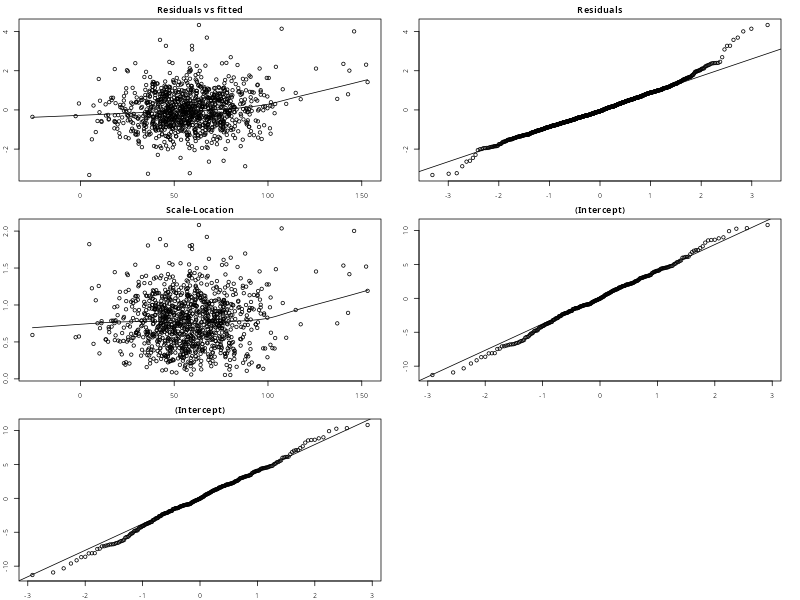

Warning message:
In plot.lme(classroom.lme) :
  Marginal covariance structure not available for more than 2 levels


In [23]:
plot.lme(classroom.lme)

Notice that this will print a warning when it is not possible to visualise the marginal covariance structure.

In terms of these plots, the distributional assumptions of the random effects appear very well-met. The distributional assumptions of the residuals less so, due to some slightly heavier tails than expected. This is no doubt due to some outliers, as can be seen on the Residual vs Fitted plot, where there are quite a few points above the standardised cut-off of 3 standard deviations. We can look at these points using

In [24]:
res.norm <- resid(classroom.lme, type="normalized", level=1, asList=FALSE)
idx      <- which(abs(res.norm) > 3)
mod.data <- nlme::getData(classroom.lme)
outliers <- mod.data[idx, ]
print(outliers)

      sex    minority mathkind mathgain   ses yearstea mathknow housepov
76   girl    minority      475      166 -0.14        6    -0.14    0.085
312  girl nonminority      542      138  2.27        9     0.43    0.050
462   boy    minority      448      -51 -0.72        1    -1.09    0.279
539   boy    minority      290      253 -0.40       25     1.57    0.257
585   boy    minority      488      142 -0.28       27     0.47    0.101
664  girl nonminority      629      -84  2.33       13     0.89    0.170
665  girl nonminority      501      179  2.00       13     0.89    0.170
754   boy    minority      368      218 -1.14        6    -0.30    0.430
812   boy nonminority      510      147 -0.47        2    -0.19    0.367
981  girl nonminority      547      133  0.28       16    -0.27    0.107
985   boy    minority      431      -28  0.56        2     0.00    0.537
1146  boy    minority      376       11  0.62       34    -1.28    0.126
     mathprep classid schoolid childid
76       2.0

A few details about this process. Firstly, we want the residuals associated with the original measurements, not the residuals at the level of classrooms or schools. This is what the `level=1` and `asList=FALSE` options are doing. We can then find the indices (row numbers) associated with those points with normalised residuals greater than 3. However, remember that `lme()` *removed* some data due to us passing the `na.omit` option. As such, the indices of the residuals will now no longer match the raw data. To solve this, we ask `nlme` to give us the data it used for the fitting, not the raw data. This what `nlme::getData()` does. This then allows us to successfully identify the correct points.

In terms of what to do with the outliers, the difficulties in these types of data are always the reasons *why* a certain point is flagged as an outlier. If it corresponds to a measurement error of some kind, then removal may be justified. Otherwise, it is difficult to argue for removal when the point represents genuine data. As an example, if we look at the value the model predicts for the first child labelled an outlier

In [25]:
predict(classroom.lme, outliers[1,])

   147/8 
67.40124 
attr(,"label")
[1] "Predicted values"

We can see that they are predicted to gain `67.40` points in maths. However, this actual student gained `166` points

In [26]:
outliers$mathgain[1]

[1] 166

which is more than the model expected. As such, they have a high residual value. But, crucially, do we think we should remove a student from the sample for *doing well*? Are high achievers automatically incorrect values and should be removed because our model does not predict them? Arguably, the answer is *no*. These students represent genuine data. Indeed, the fact that they are classes as outliers is almost the *definition* of being a high achiever. Despite their environment and personal circumstances, these children will just do very well. Removing them would artificially bias the accuracy of our model.

A similar argument can be made about outliers at the other end of the spectrum. Consider the 6th outlier identified. This student is predicted to *gain* 4.74 points over the year

In [27]:
predict(classroom.lme, outliers[6,])

   22/62 
4.738723 
attr(,"label")
[1] "Predicted values"

and yet, they actually gained

In [28]:
outliers$mathgain[6]

[1] -84

so their score went *down* dramatically, rather than going up. There could be cause to try and understand this further. Perhaps the child was ill or there were other factors influencing their performance on the day? Alternatively, it could simply be that this child has found newer material harder than others and has not been able to retain it. As a *reduction* in attainment remains possible (without any information to the contrary), we should not artificially reduce the sample to only those children with `mathgain > 0`. In reality, this is part of the consultation with domain experts to determine whether such a score is meaningful and realistic. Without this, we can only be guided by the information we have and will retain these scores.

As a final consideration, we have many variables here and concerns about multicollinearity still exist for a mixed-effects model. As such, we will consult the VIF values.

In [29]:
vif(classroom.lme)

     sex minority mathkind      ses yearstea mathprep mathknow housepov 
1.001639 1.181395 1.092153 1.102613 1.034432 1.033154 1.038698 1.095134 

As we can see, all the variables are hovering around a VIF of 1, so there is little cause for concern here.

## Inference
Finally, we get to the inference element of the analysis. Here, we stick to NHST, but recognise that alternatives are available using the `intervals()` function to produce approximate 95% confidence intervals around the estimates. However, remember that these intervals are based upon knowing the standard error of the distribution of the estimates, which we do not. 

The ANOVA table is given below.

In [30]:
Anova(classroom.lme)

Analysis of Deviance Table (Type II tests)

Response: mathgain
            Chisq Df Pr(>Chisq)    
sex        0.4691  1   0.493418    
minority  10.3609  1   0.001287 ** 
mathkind 429.9890  1  < 2.2e-16 ***
ses       16.3806  1  5.181e-05 ***
yearstea   0.1546  1   0.694143    
mathprep   0.8080  1   0.368701    
mathknow   0.5744  1   0.448534    
housepov   0.4075  1   0.523242    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

As we can see, by the standards of NHST, we have significant effects of `minority`, `mathkind` and `ses`. These are all asymptotic tests, but given that our sample at every level of the model is in the hundreds, we have fewer concerns about this approach. Interestingly, these are all suggestive that it is the characteristics of the students themselves that affects their attainment, not their learning environment. We plot all these effects below

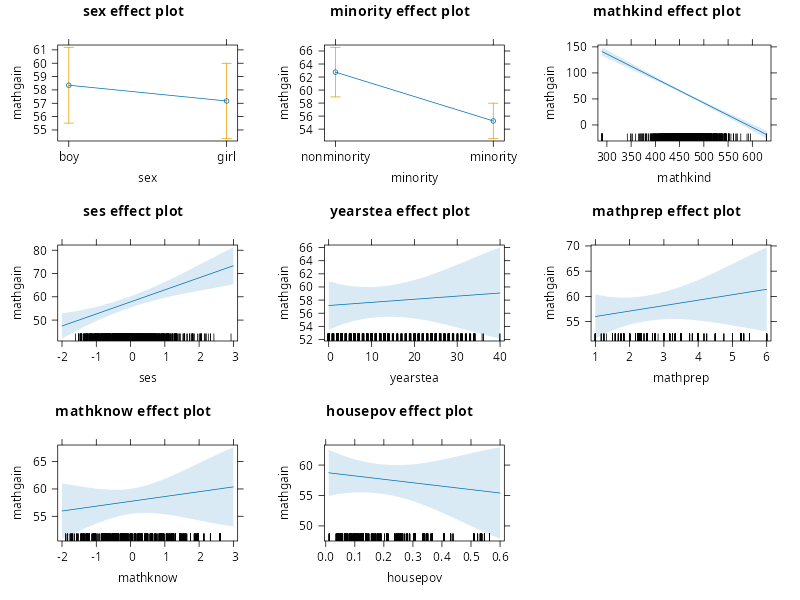

In [31]:
plot(allEffects(classroom.lme))

Of interest is that many of these effects are subtly suggestive of a relationship, but the uncertainty is very high. The clearest and most certain effects are those associated with `minority`, `mathkind` and `ses`. Given that none of these are omnibus effects, there is no need for any further testing. As such, we can conclude that the strongest predictors of a student's maths performance are as follows:

- *Minority status*
    - Children from non-minority backgrounds tend to show larger gains in maths attainment than those from minority backgrounds
- *Initial performance in Kindergarten*
    - Children who score lower in Kindergarten tend to show greater gains than those who already score higher. This may be reflective of a degree of "catching-up", especially if there are age discrepancies at play between those who score lower and higher in their initial school year.
- *Socioeconomic status* 
    - Children from a lower socioeconomic status household tend to show smaller improvements than those from higher socioeconomic status backgrounds.

However, it is important not to discount the other effects in the model. These are more subtle and much more uncertain, but are suggestive of *some* effect of individual teachers and the local school environment. However, this is much more varied as it likely depends very much on the approach of individual teachers as well as the approach of each school. 